# Demand Analysis

In [1]:
# Installing Library
!pip install statsmodels pmdarima prophet

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

# Scikit-learn
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Auto ARIMA
from pmdarima import auto_arima

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Loading Dataset

%store -r df
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,month,weekday,age_group,no_show_encoded
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,1
1,unknown,7,M,no,intellectual,ITAPEMA,morning,11,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9,1,0,...,0,0,0,0,0,1,January,Wednesday,Child,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,12,0,0,...,0,0,0,0,0,0,January,Wednesday,Teen,0


### Creating the demand target

In [4]:
# Creating a copy of actual dataset
df_ts = df.copy()

# Demand Target
daily_demand = (df_ts.groupby('appointment_date_continuous').size().reset_index(name='appointment_count'))

print(f"Shape: {df_ts.shape}")
print(f"Date range: {daily_demand['appointment_date_continuous'].min()} to {daily_demand['appointment_date_continuous'].max()}")
print(f"Min / Max : {daily_demand['appointment_count'].min()} / {daily_demand['appointment_count'].max()} appointments")
daily_demand.head()

Shape: (109593, 30)
Date range: 2020-01-01 00:00:00 to 2021-05-12 00:00:00
Min / Max : 1 / 1512 appointments


,appointment_date_continuous,appointment_count
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [5]:
# Changing the appointment dates as index
daily_demand = daily_demand.set_index('appointment_date_continuous')
daily_demand.head()

,appointment_count
appointment_date_continuous,
2020-01-01,25
2020-01-02,33
2020-01-03,18
2020-01-04,16
2020-01-05,15


#### Plotting Daily Demand - The Raw Time Series

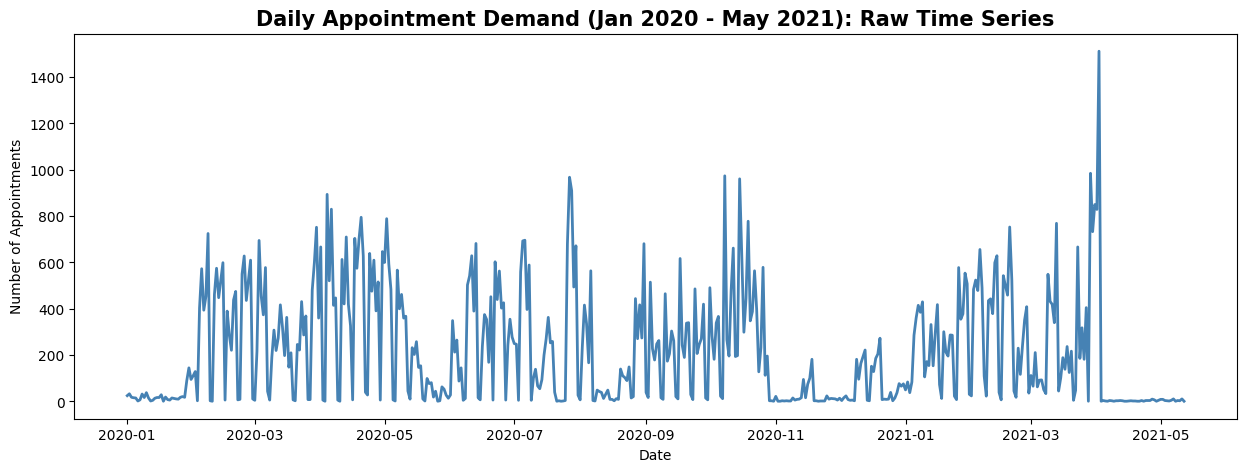

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(daily_demand.index, daily_demand['appointment_count'], color='steelblue', linewidth=2)
plt.title('Daily Appointment Demand (Jan 2020 - May 2021): Raw Time Series', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Appointments')

plt.show()

#### Chronological Split for TIME SERIES

In [7]:
# Create time index
df = daily_demand.copy()
df['time_index'] = np.arange(len(df))
X = df[['time_index']]
y = df['appointment_count']

# Chronological 80/20 split
split = int(len(df) * 0.8)

x_train = X.iloc[:split]
x_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# XGBoost using ONLY time index
xgb_b4 = XGBRegressor(n_estimator=100, max_depth=3, learning_rate=0.05, random_state=42)
xgb_b4.fit(x_train, y_train)

# Predictions
xgb_b4_pred = xgb_b4.predict(x_test)

xgb_b4_mae = mean_absolute_error(y_test, xgb_b4_pred)
xgb_b4_rmse = np.sqrt(mean_squared_error(y_test, xgb_b4_pred))
xgb_b4_wape = (np.sum(np.abs(y_test - xgb_b4_pred)) / np.sum(y_test)*100)
xgb_b4_smape = (np.mean(2*np.abs(y_test - xgb_b4_pred) / (np.abs(y_test) + np.abs(xgb_b4_pred) + 1e-8)))*100
xgb_b4_r2 = r2_score(y_test, xgb_b4_pred)

print("XGBoost - Time Index Only")
print(f"MAE  : {xgb_b4_mae:.2f}")
print(f"RMSE : {xgb_b4_rmse:.2f}")
print(f"WAPE : {xgb_b4_wape:.2f}%")
print(f"sMAPE: {xgb_b4_smape:.2f}%")
print(f"R²   : {xgb_b4_r2:.3f}")

XGBoost - Time Index Only
MAE  : 205.78
RMSE : 296.97
WAPE : 99.54%
sMAPE: 134.83%
R²   : -0.092


Forecast Results Dataframe

In [8]:
# Storing results in df

forecast_results = pd.DataFrame({
    'Model': ['XGBoost B4 Lag'],
    'MAE' : [xgb_b4_mae],
    'RMSE': [xgb_b4_rmse],
    'WAPE': [xgb_b4_wape],
    'SMAPE': [xgb_b4_smape],
    'R Square': [xgb_b4_r2]
})

forecast_results.round(2)

,Model,MAE,RMSE,WAPE,SMAPE,R Square
0,XGBoost B4 Lag,205.78,296.97,99.54,134.83,-0.09


### Autocorrelation Function (ACF) Analysis

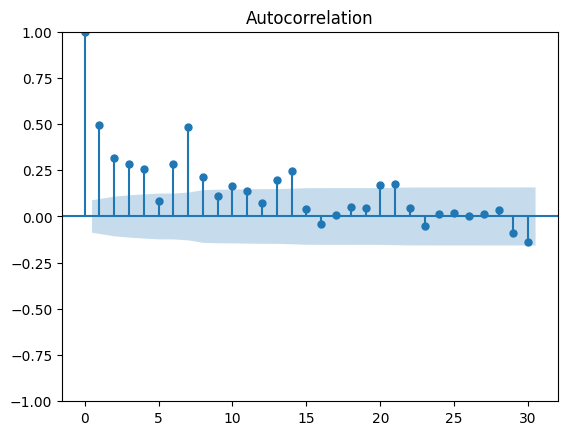

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_demand['appointment_count'].dropna(), lags=30)
plt.show()

## FEATURE ENGINEERING

#### Regression Redemption Arc — Lag Features

In [10]:
ts = daily_demand.copy()

# Lag Features
ts['lag_1'] = ts['appointment_count'].shift(1)
ts['lag_7'] = ts['appointment_count'].shift(7)
ts['lag_14'] = ts['appointment_count'].shift(14)
ts['lag_21'] = ts['appointment_count'].shift(21)
ts['lag_28'] = ts['appointment_count'].shift(28)

# Rolling Features
ts['rolling_7'] = ts['appointment_count'].shift(1).rolling(7).mean()
ts['rolling_14'] = ts['appointment_count'].shift(1).rolling(14).mean()
ts['rolling_28'] = ts['appointment_count'].shift(1).rolling(28).mean()

# Calendar Features
ts['day_of_week'] = ts.index.dayofweek # week column
ts['month'] = ts.index.month  # month column
ts['day_of_month'] = ts.index.day
ts['week_of_year'] = ts.index.isocalendar().week.astype(int)
ts['is_weekend'] = (ts.index.dayofweek >= 5).astype(int)

ts_model = ts.dropna()

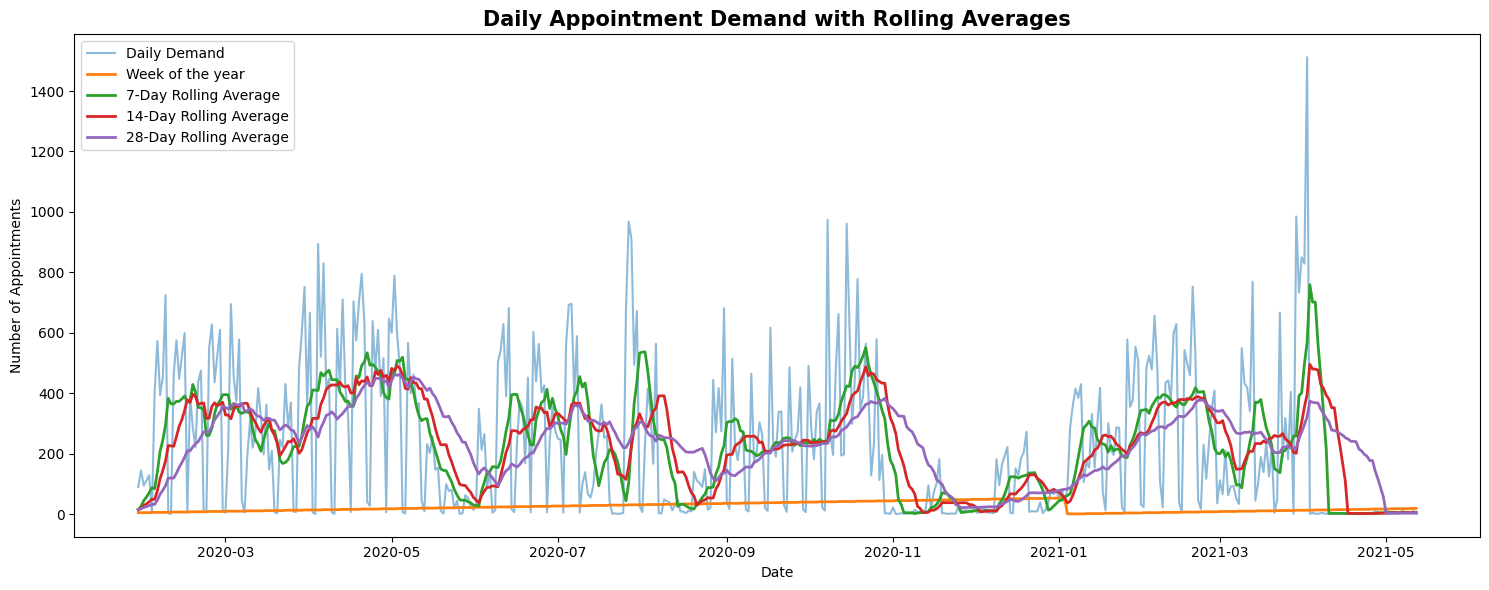

In [11]:
plt.figure(figsize=(15,6))
plt.plot(ts_model.index, ts_model['appointment_count'], alpha=0.5, label='Daily Demand')
plt.plot(ts_model.index, ts_model['week_of_year'], label='Week of the year', linewidth=2)
plt.plot(ts_model.index, ts_model['rolling_7'], label='7-Day Rolling Average', linewidth=2)
plt.plot(ts_model.index, ts_model['rolling_14'], label='14-Day Rolling Average', linewidth=2)
plt.plot(ts_model.index, ts_model['rolling_28'], label='28-Day Rolling Average', linewidth=2)

plt.title('Daily Appointment Demand with Rolling Averages', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Appointments')
plt.legend()
plt.tight_layout()
plt.show()

#### Comparison of Regression with and without Lag Features

In [12]:
# Dependent and Independent Variable
X = ts.drop('appointment_count', axis=1)
y = ts['appointment_count']

# Chronological 80/20 split
split = int(len(df) * 0.8)

x_train_lag = X.iloc[:split]
x_test_lag = X.iloc[split:]

y_train_lag = y.iloc[:split]
y_test_lag = y.iloc[split:]

# Predictions
xgb_b4.fit(x_train_lag, y_train_lag)
xgb_b4_pred_lag = xgb_b4.predict(x_test_lag)

xgb_lag_mae = mean_absolute_error(y_test_lag, xgb_b4_pred_lag)
xgb_lag_rmse = np.sqrt(mean_squared_error(y_test_lag, xgb_b4_pred_lag))
xgb_lag_wape = (np.sum(np.abs(y_test_lag - xgb_b4_pred_lag)) / np.sum(y_test)*100)
xgb_lag_smape = (np.mean(2*np.abs(y_test_lag - xgb_b4_pred_lag) / (np.abs(y_test_lag) + np.abs(xgb_b4_pred_lag) + 1e-8)))*100
xgb_lag_r2 = r2_score(y_test_lag, xgb_b4_pred_lag)

print("XGBoost - Time Index Only")
print(f"MAE  : {xgb_lag_mae:.2f}")
print(f"RMSE : {xgb_lag_rmse:.2f}")
print(f"WAPE : {xgb_lag_wape:.2f}%")
print(f"sMAPE: {xgb_lag_smape:.2f}%")
print(f"R²   : {xgb_lag_r2:.3f}")

XGBoost - Time Index Only
MAE  : 183.21
RMSE : 265.40
WAPE : 88.63%
sMAPE: 117.17%
R²   : 0.128


In [13]:
# Storing it in Forecast_results df

forecast_results.loc[len(forecast_results)] = ['XGBoost with lag', xgb_lag_mae, xgb_lag_rmse, xgb_lag_wape, xgb_lag_smape, xgb_lag_r2]
forecast_results

,Model,MAE,RMSE,WAPE,SMAPE,R Square
0,XGBoost B4 Lag,205.776093,296.974194,99.543388,134.826032,-0.092095
1,XGBoost with lag,183.205627,265.404541,88.625008,117.165584,0.127753


### Exploratory Data Analysis (EDA)

#### Seasonal Decomposition

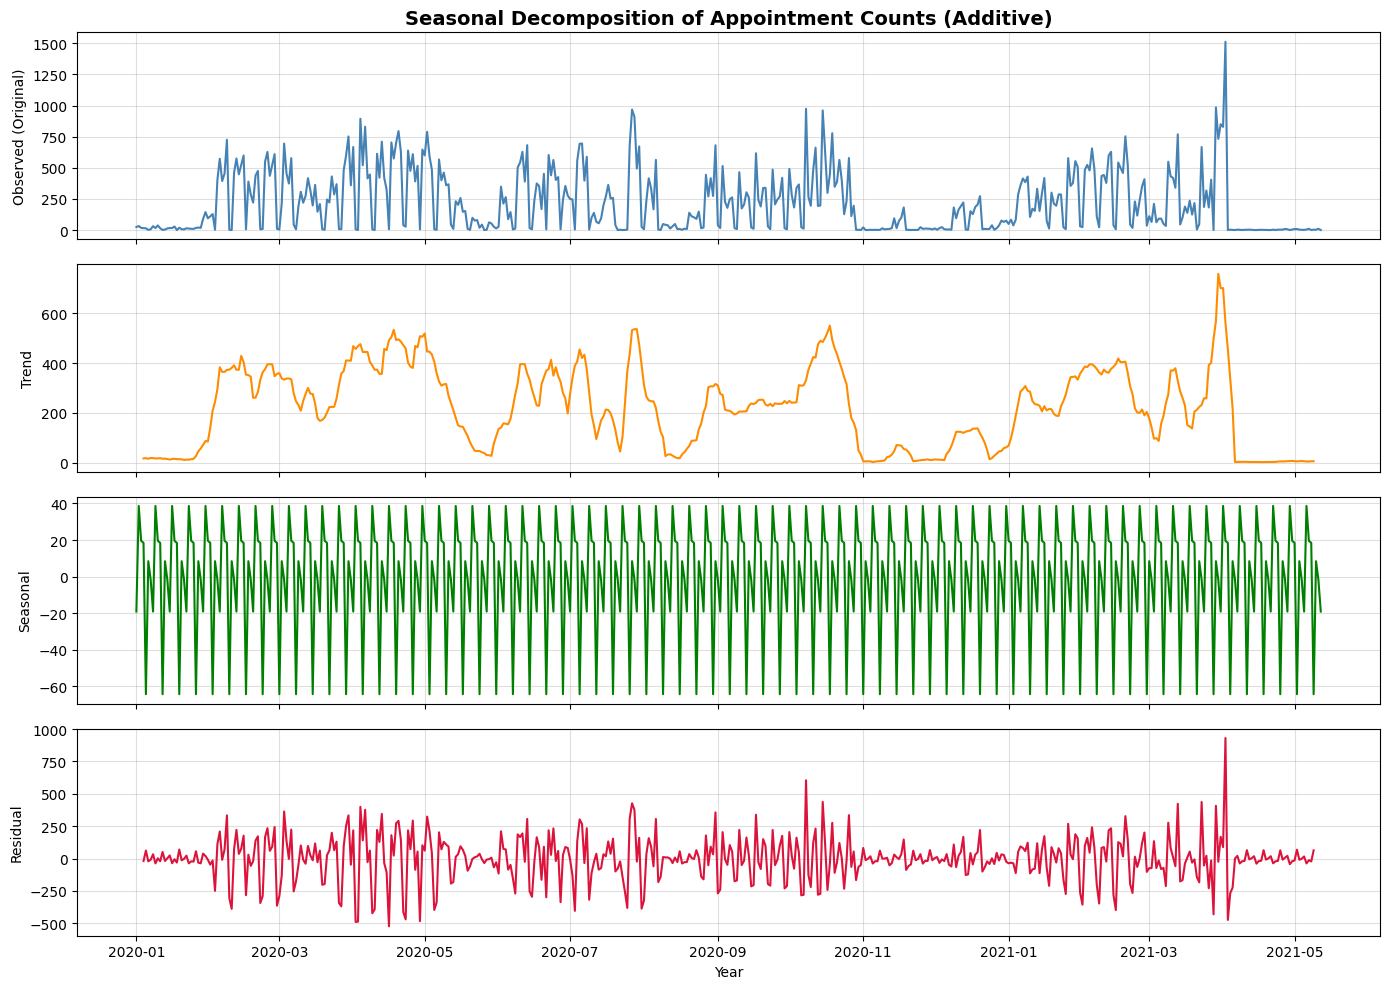

In [14]:
decomposition = seasonal_decompose(daily_demand['appointment_count'],model='additive',period=7)

fig, axes = plt.subplots(4, 1, figsize=(14,10), sharex=True)
components = {
    'Observed (Original)': daily_demand['appointment_count'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}
colors = ['steelblue','darkorange','green','crimson']

for ax, (title, data), color in zip(axes, components.items(), colors):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.4)

axes[0].set_title('Seasonal Decomposition of Appointment Counts (Additive)', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

In [15]:
# Rolling Mean - Visual Stationarity Check

rolling_mean7 = daily_demand['appointment_count'].rolling(window=7).mean()
rolling_std7 = daily_demand['appointment_count'].rolling(window=7).std()

rolling_mean14 = daily_demand['appointment_count'].rolling(window=14).mean()
rolling_std14 = daily_demand['appointment_count'].rolling(window=14).std()

rolling_mean28 = daily_demand['appointment_count'].rolling(window=28).mean()
rolling_std28 = daily_demand['appointment_count'].rolling(window=28).std()

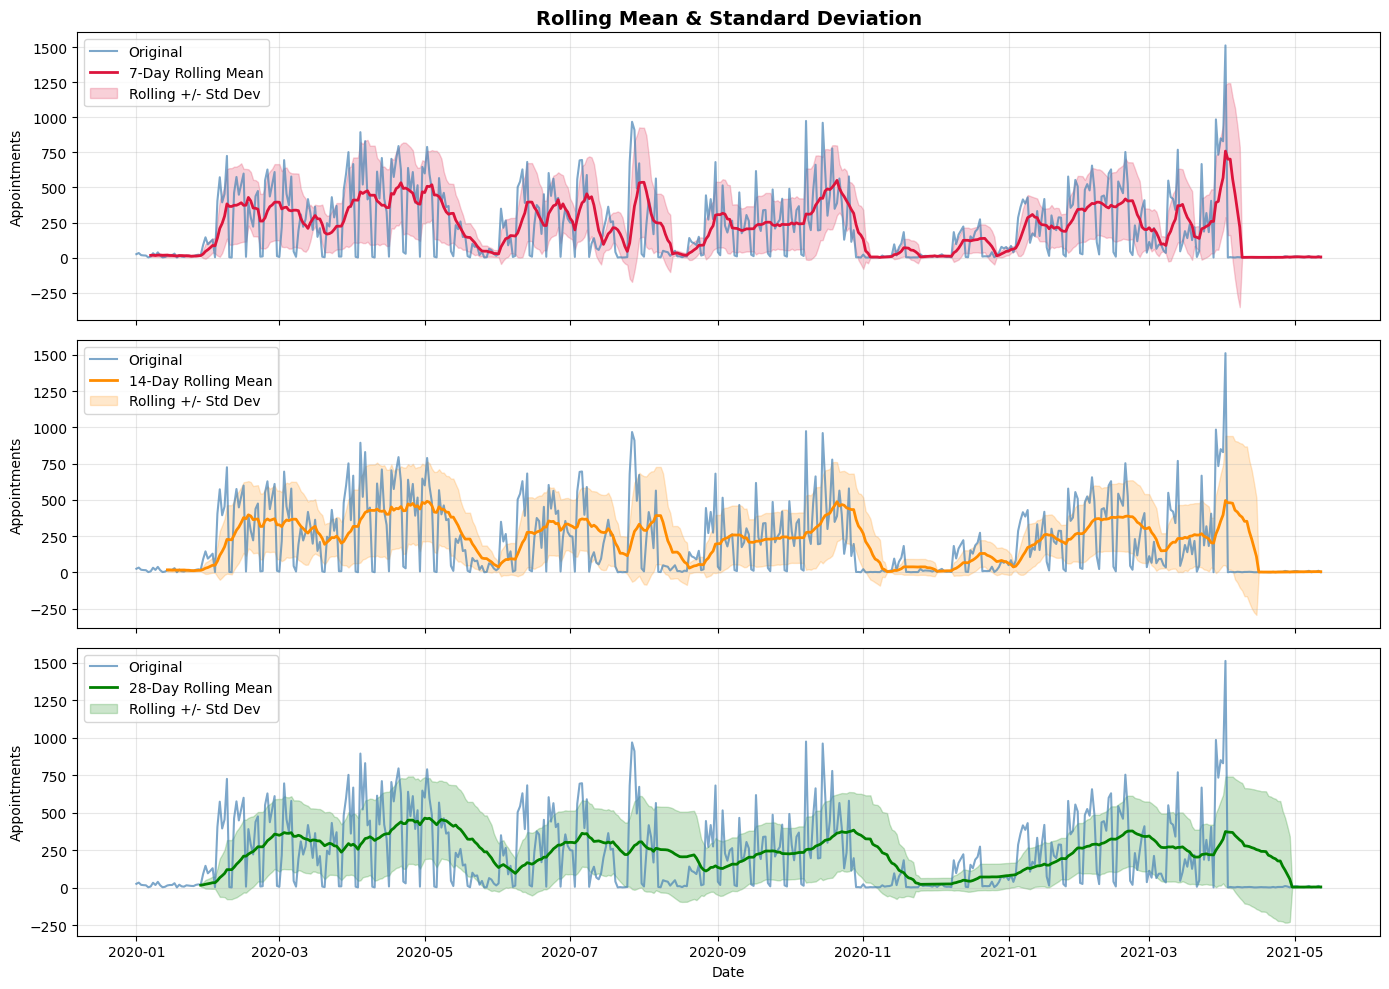

In [16]:
# Store rolling statistics
components = {7:(rolling_mean7, rolling_std7), 14:(rolling_mean14, rolling_std14), 28:   (rolling_mean28, rolling_std28)}

colors = {7:'crimson', 14:'darkorange', 28:'green'}

fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

for ax, (window, (mean, std)) in zip(axes, components.items()):
    color = colors[window]

    # Original Series
    ax.plot(daily_demand['appointment_count'], label='Original', color='steelblue', alpha=0.7, linewidth=1.5)

    # Rolling mean
    ax.plot(mean, label=f'{window}-Day Rolling Mean', color=color, linewidth=2)

    # Rolling standard deviation band
    ax.fill_between(daily_demand.index, mean-std, mean+std, alpha=0.2, color=color, label='Rolling +/- Std Dev')
    ax.set_ylabel('Appointments')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title('Rolling Mean & Standard Deviation', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

The rolling mean and standard deviation vary considerably over time across 7-day, 14-day, and 28-day windows. The changing mean indicates that the appointment-demand series does not have a stable level, while the changing standard deviation indicates non-constant variance. Therefore, the visual analysis suggests that the original daily appointment-demand series is non-stationary.

#### Monthly Seasonality

In [17]:
monthly_demand = daily_demand.copy()

monthly_demand = daily_demand.copy()
monthly_demand['Month'] = monthly_demand.index.strftime('%b')
monthly_demand['Year'] = monthly_demand.index.year

# Monthly demand by Year and Month
mon_dem = (monthly_demand.groupby(['Year', 'Month'])['appointment_count'].sum().reset_index())

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mon_dem['Month'] = pd.Categorical(mon_dem['Month'],categories=month_order,ordered=True)
mon_dem = mon_dem.sort_values(['Year', 'Month'])

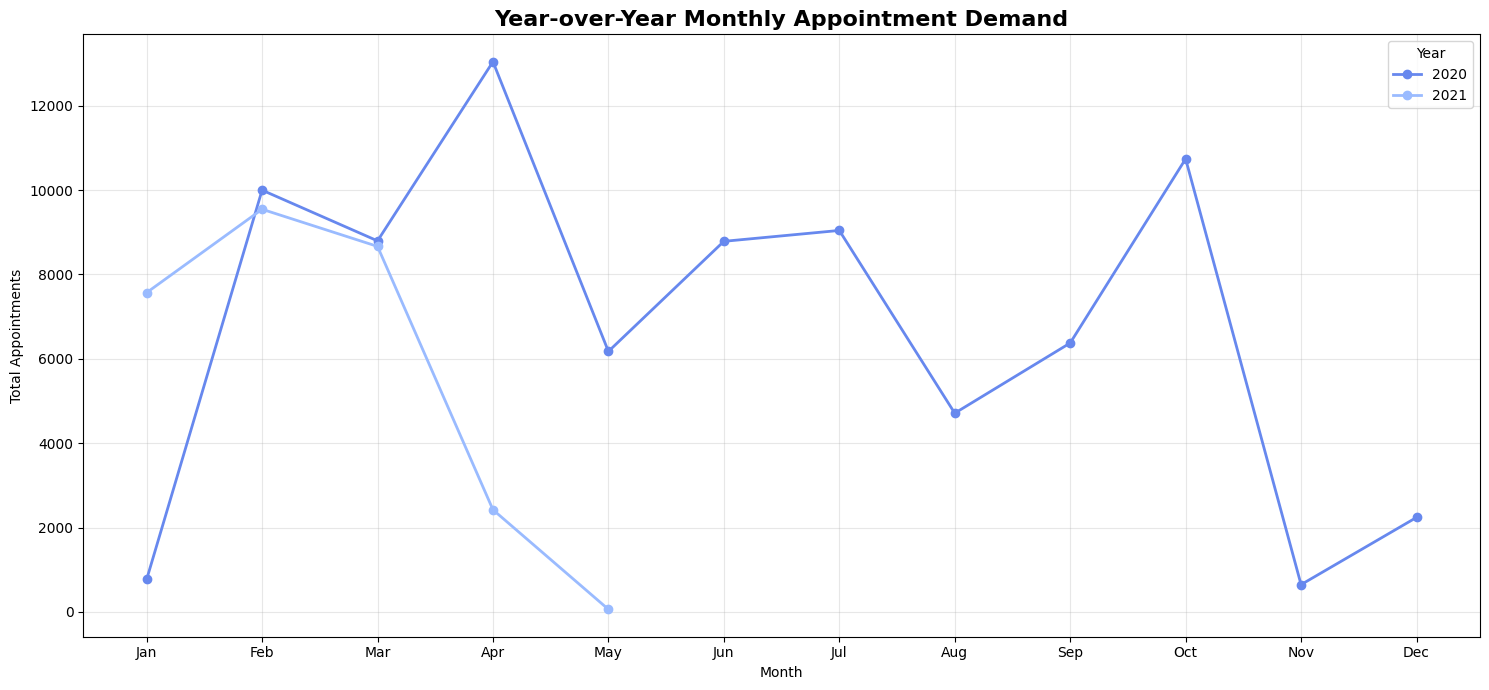

In [18]:
plt.figure(figsize=(15, 7))

sns.set_palette('coolwarm')
for year in mon_dem['Year'].unique():
    year_data = mon_dem[mon_dem['Year'] == year]
    plt.plot(year_data['Month'],year_data['appointment_count'],marker='o',linewidth=2,label=str(year))

plt.title('Year-over-Year Monthly Appointment Demand', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(month_order)
plt.grid(True, alpha=0.3)
plt.legend(title='Year')

plt.tight_layout()
plt.show()

Year-over-year analysis indicates that appointment demand varies considerably across months. February and March show relatively consistent demand across 2020 and 2021, suggesting some recurring monthly patterns. However, substantial differences between corresponding months, particularly the sharp decline after March 2021, indicate that demand is also influenced by structural changes or external factors. Therefore, monthly seasonality alone is insufficient to explain the demand pattern, and forecasting models should incorporate short-term lag effects, weekly seasonality, and calendar features

##### Day-of-week Analysis

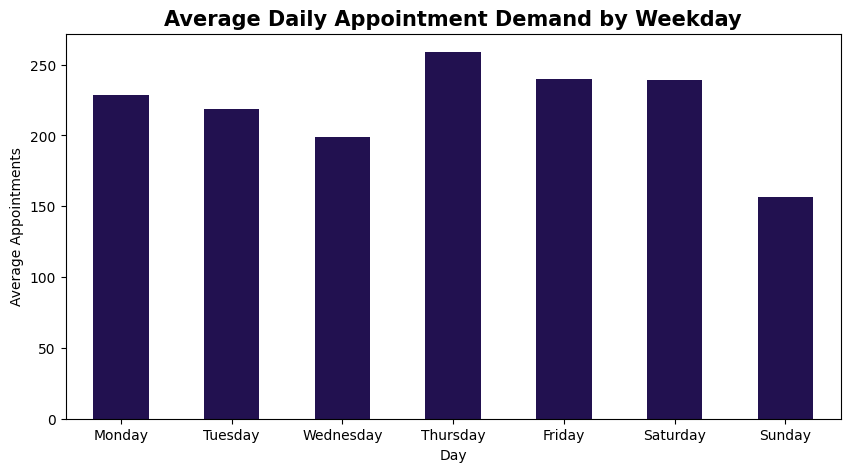

In [19]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tsd = daily_demand.copy()
tsd['Day_of_Week'] = tsd.index.day_name()

weekday_demand = (tsd.groupby('Day_of_Week')['appointment_count'].mean().reindex(weekday_order))

# Plotting Day of Week Analysis
sns.set_palette('magma')
weekday_demand.plot(kind='bar', figsize=(10,5))
plt.title('Average Daily Appointment Demand by Weekday', fontsize=15, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Appointments')
plt.xticks(rotation=0)
plt.show()

# Forecasting Preparation

### Chronological Train/Test Split

Training set : 2020-01-01 00:00:00 to 2021-02-01 00:00:00 (13 Months)
Test set : 2021-02-02 00:00:00 to 2021-05-12 00:00:00 (3 Months)


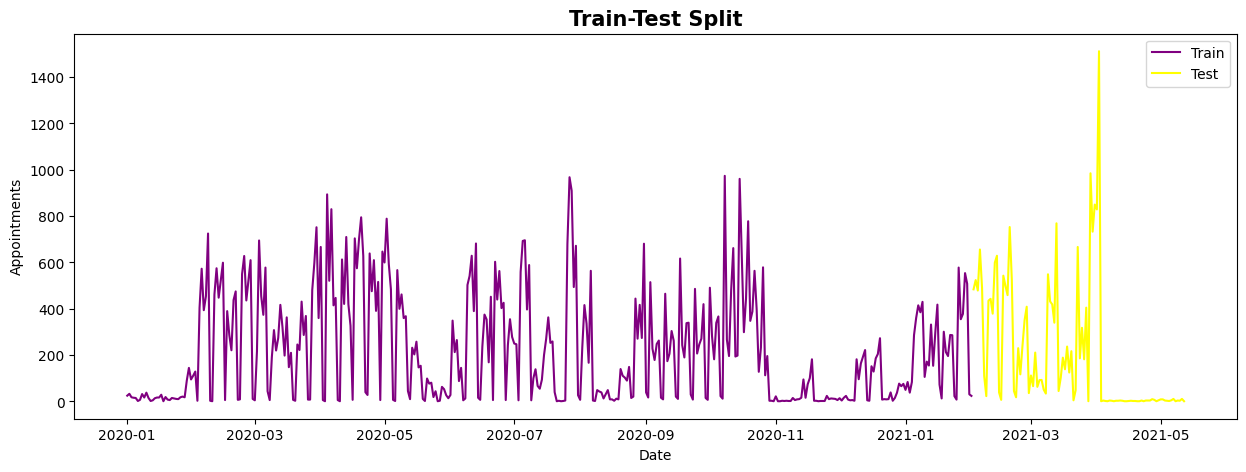

In [20]:
split_index = int(len(daily_demand) * 0.8) # 20% data for testing and 80% data for training

train = daily_demand.iloc[:split_index]
test = daily_demand.iloc[split_index:]

print(f"Training set : {train.index.min()} to {train.index.max()} (13 Months)")
print(f"Test set : {test.index.min()} to {test.index.max()} (3 Months)")

plt.figure(figsize=(15,5))

sns.set_palette('coolwarm')
plt.plot(train.index, train['appointment_count'], label='Train',color='purple')
plt.plot(test.index, test['appointment_count'], label='Test',color='yellow')

plt.title('Train-Test Split', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Appointments')
plt.legend()

plt.show()

### 1. Baseline Models

In [21]:
# Evaluation  - HELPER

def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    wape = (np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))) * 100
    smape = np.mean(2*abs(actual - predicted) / (np.abs(actual) + np.abs(predicted)+ 1e-8))*100
    r2 = r2_score(actual, predicted)
    print(f"{model_name:<35} MAE={mae:6.1f} RMSE={rmse:6.1f} MAPE= {mape:5.2f}%")
    return {'Model': model_name, 'MAE':round(mae,2), 'RMSE':round(rmse,2), 'WAPE':round(wape,2), 'SMAPE':round(smape,2), 'R_Square':round(r2,2)}

evaluation_results = []

# Baseline 1: Naive Forecast
naive_pred = pd.Series([train['appointment_count'].iloc[-1]] * len(test), index=test.index)
evaluation_results.append(evaluate(test['appointment_count'].values, naive_pred, 'Naive Forecast'))
# Adding to forecast_results df
forecast_results.loc[len(forecast_results)] = [evaluation_results[0].get('Model'), evaluation_results[0].get('MAE'),
                                               evaluation_results[0].get('RMSE'), evaluation_results[0].get('WAPE'),
                                               evaluation_results[0].get('SMAPE'), evaluation_results[0].get('R_Square')]

# Baseline 2: Seasonal Naive
sn = train['appointment_count'][-7:]
seasonal_naive_pred = np.tile(sn, int(np.ceil(len(test)/7)))[:len(test)]
seasonal_naive_pred = pd.Series(seasonal_naive_pred, index=test.index)
evaluation_results.append(evaluate(test['appointment_count'], seasonal_naive_pred.values, 'Seasonal Naive (lag-7)'))
# Adding to forecast_results df
forecast_results.loc[len(forecast_results)] = [evaluation_results[1].get('Model'), evaluation_results[1].get('MAE'),
                                               evaluation_results[1].get('RMSE'), evaluation_results[1].get('WAPE'),
                                               evaluation_results[1].get('SMAPE'), evaluation_results[1].get('R_Square')]

# Baseline 3: Moving Average
ma_val = train['appointment_count'].rolling(7).mean().iloc[-1]
ma_pred = pd.Series([ma_val] * len(test), index=test.index)
evaluation_results.append(evaluate(test['appointment_count'], ma_pred.values, '7-Week Moving Average'))
# Adding to forecast_results df
forecast_results.loc[len(forecast_results)] = [evaluation_results[2].get('Model'), evaluation_results[2].get('MAE'),
                                               evaluation_results[2].get('RMSE'), evaluation_results[2].get('WAPE'),
                                               evaluation_results[2].get('SMAPE'), evaluation_results[2].get('R_Square')]

print()
print('These are the benchmarks. A good model MUST beat Seasonal Naive.\n')
print(forecast_results.round(2))

Naive Forecast                      MAE= 200.3 RMSE= 337.9 MAPE= 494.90%
Seasonal Naive (lag-7)              MAE= 240.4 RMSE= 328.5 MAPE= 7322.14%
7-Week Moving Average               MAE= 282.0 RMSE= 316.9 MAPE= 7183.31%

These are the benchmarks. A good model MUST beat Seasonal Naive.

                    Model     MAE    RMSE    WAPE   SMAPE  R Square
0          XGBoost B4 Lag  205.78  296.97   99.54  134.83     -0.09
1        XGBoost with lag  183.21  265.40   88.63  117.17      0.13
2          Naive Forecast  200.34  337.85   96.91  148.19     -0.41
3  Seasonal Naive (lag-7)  240.45  328.47  116.32  109.06     -0.34
4   7-Week Moving Average  282.04  316.85  136.43  126.80     -0.24


### ARIMA - AutoRegressive Integrated Moving Average

ARIMA(p,d,q)
* AutoRegressive (AR) -> Using past values as features (lag features)  -> p = how many lags
* Integrated -> Data tranformation to stabilise the series  -> d = how many times to difference
* Moving Average -> Learning from past prediction errors  -> q = how many error lags

* p: "Look back p months and use those values to predict now" → like lag_1, lag_2, ..., lag_p features in regression
* d: "Transform the data d times until it is stable" → like log-scaling to stabilise variance
* q: "Also learn from my last q prediction mistakes" → like residual feedback / error correction

In [22]:
# Auto Arima to find best (p,d,q)

arima_auto = auto_arima(train['appointment_count'], seasonal=False, #plain ARIMA, no seasonality handling (showing its limits first)
                        stepwise=True, information_criterion='aic', trace=True, error_action='ignore', suppress_warnings=True)

print(f"\\nBest ARIMA order: {arima_auto.order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5350.375, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5476.815, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5438.319, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5369.816, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5474.815, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=5350.092, Time=0.58 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=5348.135, Time=0.25 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=5350.082, Time=0.52 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5350.069, Time=0.33 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=5351.044, Time=0.81 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=5346.247, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=5367.878, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=5348.206, Time=0.43 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=5348.196, Time=0.31 sec
 ARIMA(1,1,1)(0,0,0)[0]          

In [23]:
# Fit ARIMA and Forecast

arima_model = ARIMA(train['appointment_count'], order=arima_auto.order)
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

evaluation_results.append(evaluate(test['appointment_count'].values, arima_forecast.values, f'ARIMA{arima_auto.order}'))
forecast_results.loc[len(forecast_results)] = [evaluation_results[3].get('Model'), evaluation_results[3].get('MAE'),
                                               evaluation_results[3].get('RMSE'), evaluation_results[3].get('WAPE'),
                                               evaluation_results[3].get('SMAPE'), evaluation_results[3].get('R_Square')]

ARIMA(0, 1, 2)                      MAE= 242.1 RMSE= 287.5 MAPE= 5118.32%


C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


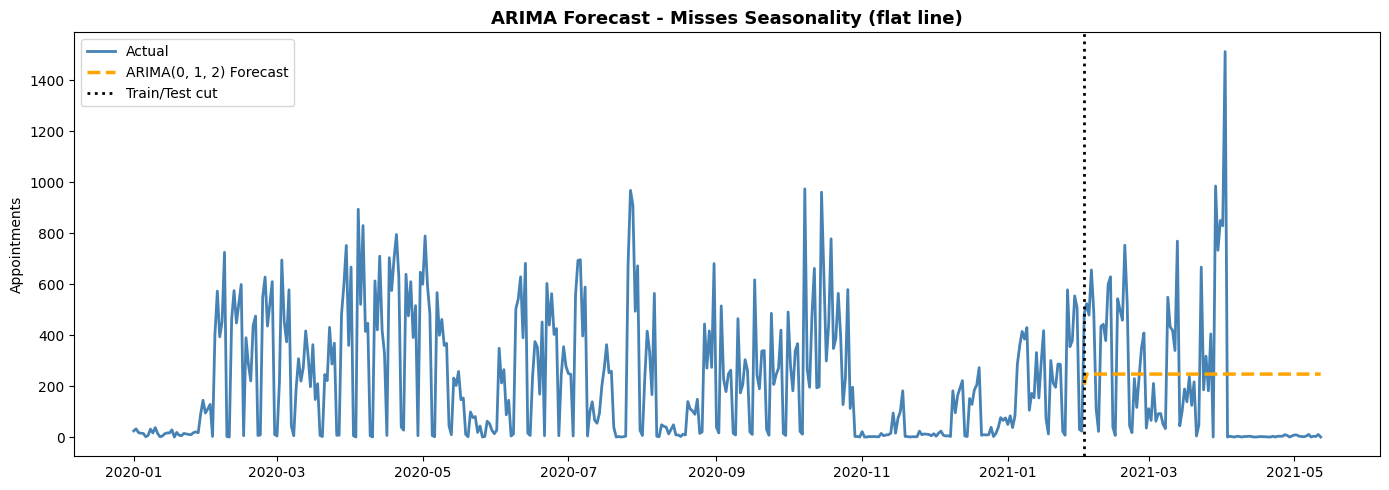

In [24]:
# Plot
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(ts.index, ts['appointment_count'], label='Actual', color='steelblue', linewidth=2)
ax.plot(test.index, arima_forecast, label=f'ARIMA{arima_auto.order} Forecast', color='orange', linewidth=2.5, linestyle='--')

ax.axvline(test.index[0], color='black', linestyle=':', linewidth=2, label='Train/Test cut')
ax.set_title('ARIMA Forecast - Misses Seasonality (flat line)', fontsize=13, fontweight='bold')
ax.set_ylabel('Appointments')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
forecast_results

,Model,MAE,RMSE,WAPE,SMAPE,R Square
0,XGBoost B4 Lag,205.776093,296.974194,99.543388,134.826032,-0.092095
1,XGBoost with lag,183.205627,265.404541,88.625008,117.165584,0.127753
2,Naive Forecast,200.340000,337.850000,96.910000,148.190000,-0.410000
3,Seasonal Naive (lag-7),240.450000,328.470000,116.320000,109.060000,-0.340000
4,7-Week Moving Average,282.040000,316.850000,136.430000,126.800000,-0.240000
5,"ARIMA(0, 1, 2)",242.080000,287.490000,117.100000,128.700000,-0.020000


ARIMA has a lower RMSE than Seasonal Naive → it handles the large forecasting errors somewhat better.
Seasonal Naive has a lower MAE → its typical absolute error is smaller.
Both have negative R², meaning neither model explains the test-period demand variation well enough yet.
Your demand has a strong weekly pattern, so ordinary ARIMA (1,1,1) is not accounting for that seasonality.

### SARIMA - Seasonal AutoRegressive Integrated Moving Average

##### SARIMA = Seasonal ARIMA - full notation: SARIMA(p,d,q)(P,D,Q,m)

The second set of parameters works exactly like (p,d,q) but operates on the seasonal lag
* P -> Season AR Term  ->  Use values from m months ago as features
* D -> Seasonal differencing  -> Remove the seasonal trend by differencing at lag m
* Q -> Seasonal MA term  -> Learn from errors made at the same season last cycle
* m -> Seasonal length  -> 12 for montly data with yearly seasonality 

In [26]:
# Auto_Sarima with seasonality (m=12 for montly/yearly cycle)

sarima_auto = auto_arima(train['appointment_count'],seasonal=True,m=7,stepwise=True,information_criterion='aic',trace=True,
                         error_action='ignore',suppress_warnings=True,D=1)

print(f"\\nBest SARIMA (p,d,q) : {sarima_auto.order}")
print(f"Best Seasonal (P,D,Q,m) : {sarima_auto.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=inf, Time=2.27 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=5331.254, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=5224.902, Time=0.40 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=5249.460, Time=0.46 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=5329.537, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=5229.593, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=5194.338, Time=0.89 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=1.69 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=0.86 sec
 ARIMA(0,0,0)(2,1,0)[7] intercept   : AIC=5296.282, Time=1.31 sec
 ARIMA(2,0,0)(2,1,0)[7] intercept   : AIC=5184.584, Time=1.04 sec
 ARIMA(2,0,0)(1,1,0)[7] intercept   : AIC=5214.182, Time=0.49 sec
 ARIMA(2,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=1.96 sec
 ARIMA(2,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=1.07 sec
 ARIMA(3,0,0)(2,1,0)[7] intercept   : AIC=5182.718, Time=1

C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(5, 0, 1)(2, 1, 0, 7)         MAE= 217.6 RMSE= 295.5 MAPE= 6056.12%


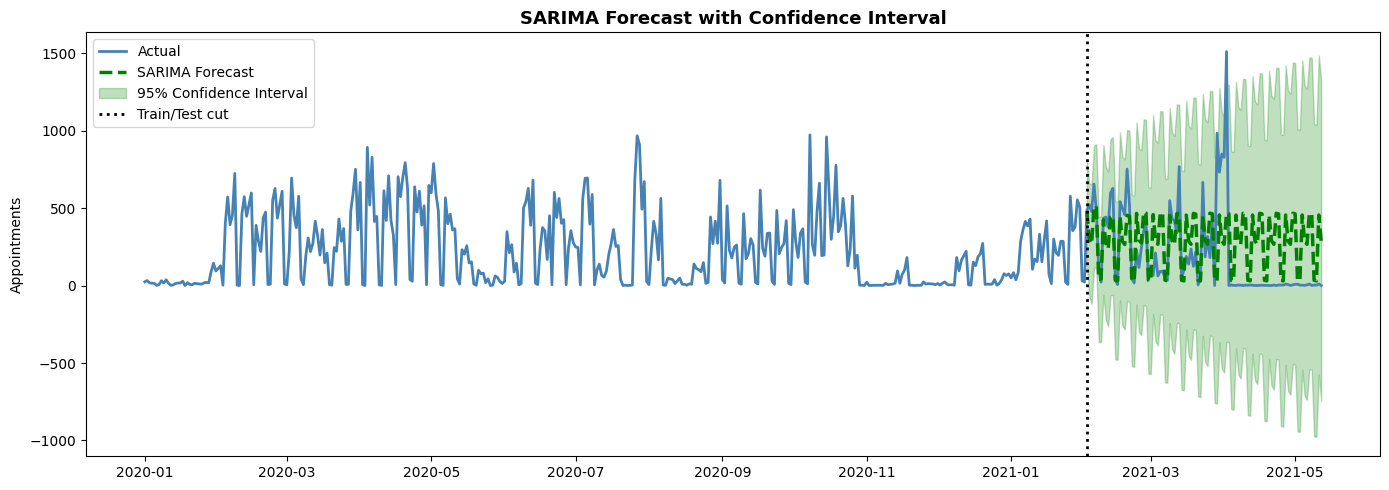

In [27]:
# Fit SARIMA and Forecast

sarima_model = SARIMAX(train['appointment_count'], order = sarima_auto.order, seasonal_order = sarima_auto.seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

sarima_fc = sarima_fit.forecast(steps=len(test))
sarima_fc = pd.Series(sarima_fc.values, index=test.index)

evaluation_results.append(evaluate(test['appointment_count'], sarima_fc.values, f"SARIMA{sarima_auto.order}{sarima_auto.seasonal_order}"))
forecast_results.loc[len(forecast_results)] = [evaluation_results[4].get('Model'), evaluation_results[4].get('MAE'),
                                               evaluation_results[4].get('RMSE'), evaluation_results[4].get('WAPE'),
                                               evaluation_results[4].get('SMAPE'), evaluation_results[4].get('R_Square')]

# Get confidence intervals for uncertainty bands
pred_ci = sarima_fit.get_forecast(steps=len(test)).conf_int()

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(daily_demand['appointment_count'], label='Actual', color='steelblue', linewidth=2)
ax.plot(sarima_fc, label='SARIMA Forecast', color='green', linewidth=2.5, linestyle='--')
ax.fill_between(test.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                alpha=0.25, color='green', label='95% Confidence Interval')
ax.axvline(test.index[0], color='black', linestyle=':', linewidth=2, label='Train/Test cut')
ax.set_title('SARIMA Forecast with Confidence Interval', fontsize=13, fontweight='bold')
ax.set_ylabel('Appointments')
ax.legend(); plt.tight_layout(); plt.show()

SARIMA successfully captures the weekly seasonal pattern in daily appointment demand, but it struggles to capture the large fluctuations and extreme demand spikes observed in the actual data. The forecast becomes relatively repetitive over the long-term horizon, while the widening confidence interval indicates substantial uncertainty. Therefore, although SARIMA performs better than the basic ARIMA model in some evaluation metrics, it is not sufficiently accurate for reliable long-term demand forecasting.

#### SARIMAX : Adding External Variables 

SARIMAX = SARIMA + Exogenous variables 

Exogenous variables = external features that are not the target variable itself


In [28]:
# Having Weather as exogenous variable

daily_exog = (df_ts.groupby('appointment_date_continuous').agg({
    'average_temp_day': 'mean',
    'max_temp_day': "mean",
    'average_rain_day':'mean',
    'max_rain_day':'mean'
})).round(2)

daily_exog.head()

,average_temp_day,max_temp_day,average_rain_day,max_rain_day
appointment_date_continuous,,,,
2020-01-01,21.11,24.70,0.09,1.76
2020-01-02,20.80,24.68,0.16,2.20
2020-01-03,20.99,24.68,0.21,2.19
2020-01-04,20.42,23.98,0.05,0.64
2020-01-05,21.15,24.20,0.40,5.38


In [29]:
exog_train = daily_exog.loc[train.index]
exog_test = daily_exog.loc[test.index]

print("Sample exogenous variable")
print(exog_train.head(15).T)
print()

# Fit SARIMAX
sarimax_model = SARIMAX(train['appointment_count'], exog = exog_train, order = sarima_auto.order, seasonal_order = sarima_auto.seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_fc = sarimax_fit.forecast(steps=len(test), exog=exog_test)
sarimax_fc = pd.Series(sarimax_fc.values, index=test.index)

evaluation_results.append(evaluate(test['appointment_count'].values, sarimax_fc.values, 'SARIMAX + Exogenous variable'))
forecast_results.loc[len(forecast_results)] = [evaluation_results[5].get('Model'), evaluation_results[5].get('MAE'),
                                               evaluation_results[5].get('RMSE'), evaluation_results[5].get('WAPE'),
                                               evaluation_results[5].get('SMAPE'), evaluation_results[5].get('R_Square')]

Sample exogenous variable
appointment_date_continuous  2020-01-01  2020-01-02  2020-01-03  2020-01-04  \
average_temp_day                  21.11       20.80       20.99       20.42   
max_temp_day                      24.70       24.68       24.68       23.98   
average_rain_day                   0.09        0.16        0.21        0.05   
max_rain_day                       1.76        2.20        2.19        0.64   

appointment_date_continuous  2020-01-05  2020-01-06  2020-01-07  2020-01-08  \
average_temp_day                  21.15       24.48       19.19       20.03   
max_temp_day                      24.20       28.65       21.71       23.20   
average_rain_day                   0.40        0.36        0.10        0.15   
max_rain_day                       5.38        3.90        0.91        1.90   

appointment_date_continuous  2020-01-09  2020-01-10  2020-01-11  2020-01-12  \
average_temp_day                  19.81       21.26       19.95       16.70   
max_temp_day            

C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mubi_\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX + Exogenous variable        MAE= 217.9 RMSE= 295.4 MAPE= 6071.75%


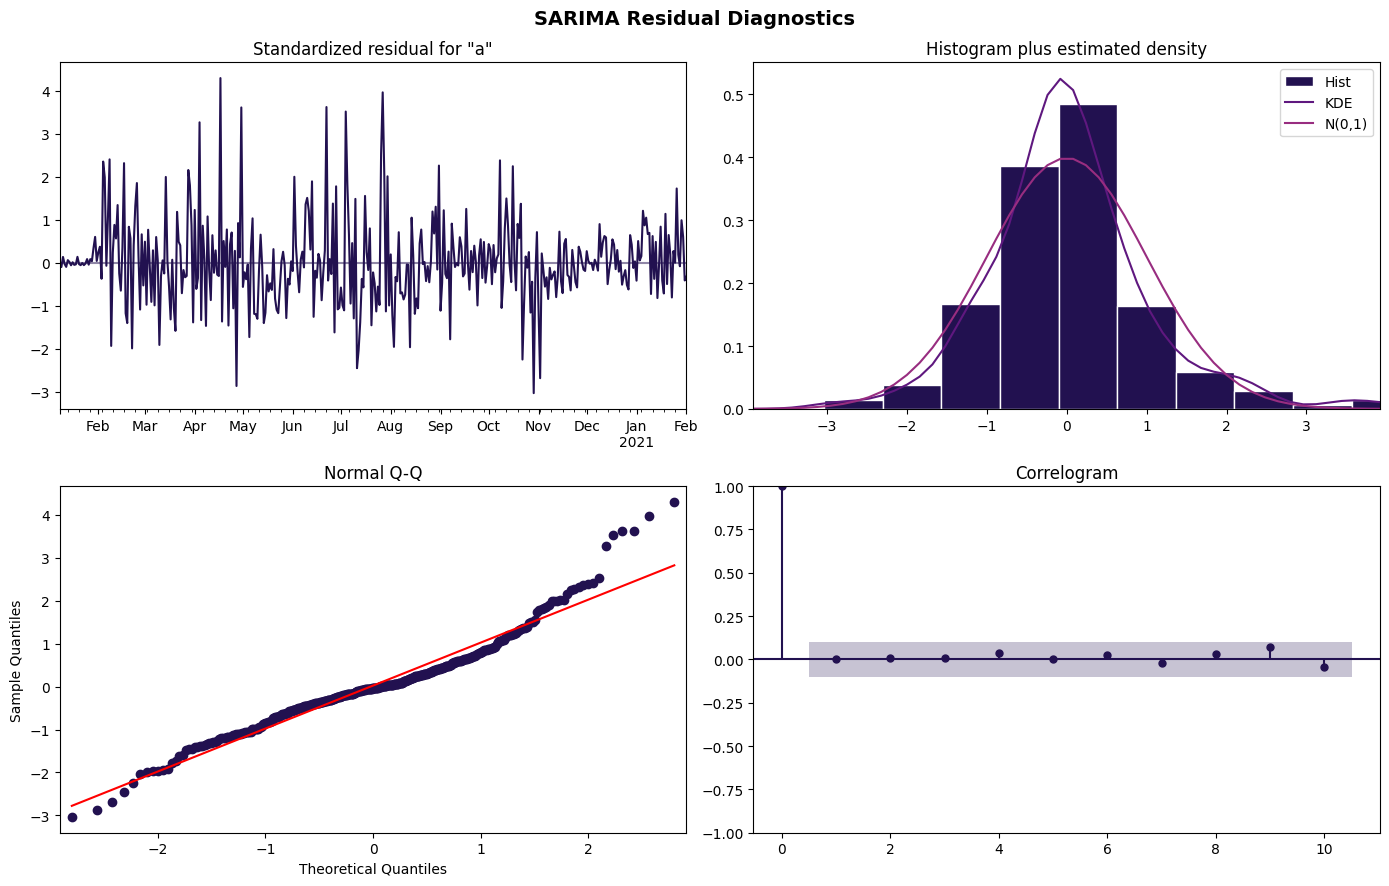

In [30]:
# Residual Diagnostics for SARIMA

sns.set_palette('magma')
fig = sarima_fit.plot_diagnostics(figsize=(14,9))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Running walk-forward validation for 100 steps
SARIMA Walk-Forward Validation      MAE= 168.6 RMSE= 254.7 MAPE= 4144.31%


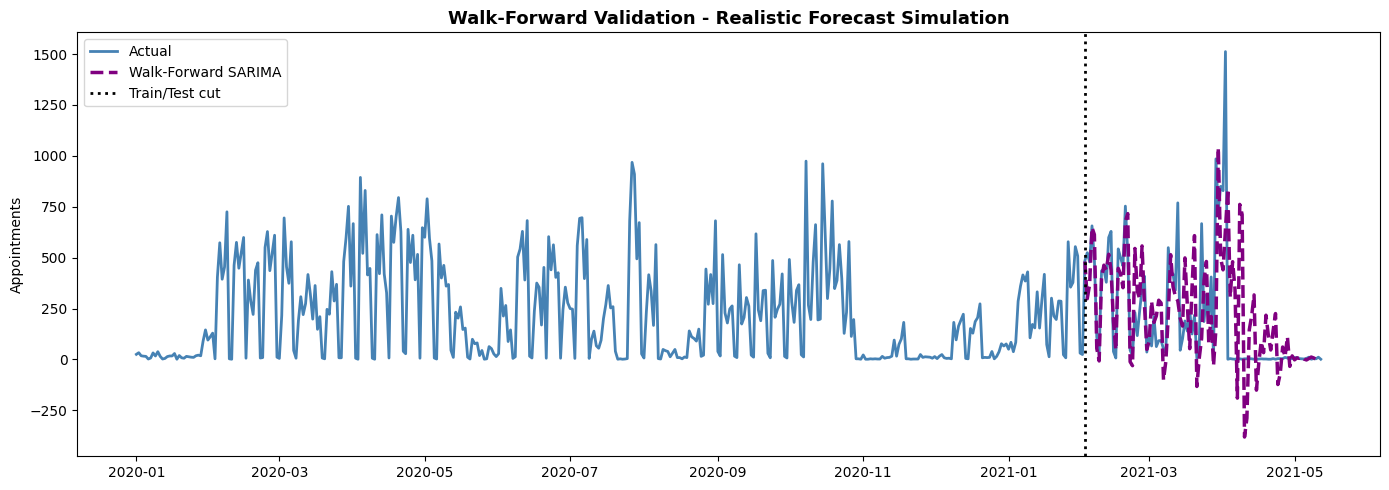

In [31]:
# Rolling Validation
# Simulate real forecasting: train on all data up to time, t predict t+1, roll forward

history = list(train['appointment_count'])
wf_predictions = []

print(f"Running walk-forward validation for {len(test)} steps")
for t in range(len(test)):
    model = SARIMAX(history,
                    order = sarima_auto.order, 
                    seasonal_order = sarima_auto.seasonal_order)
    model_fit = model.fit(disp=False)
    yhat = model_fit.forecast(steps=1)[0]
    wf_predictions.append(yhat)
    history.append(test['appointment_count'].iloc[t])

wf_predictions = pd.Series(wf_predictions, index=test.index)
evaluation_results.append(evaluate(test['appointment_count'].values, wf_predictions.values, 'SARIMA Walk-Forward Validation'))
forecast_results.loc[len(forecast_results)] = [evaluation_results[6].get('Model'), evaluation_results[6].get('MAE'),
                                               evaluation_results[6].get('RMSE'), evaluation_results[6].get('WAPE'),
                                               evaluation_results[6].get('SMAPE'), evaluation_results[6].get('R_Square')]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(daily_demand['appointment_count'], label='Actual', color='steelblue', linewidth=2)
ax.plot(test.index, wf_predictions, label='Walk-Forward SARIMA',
        color='purple', linewidth=2.5, linestyle='--')
ax.axvline(test.index[0], color='black', linestyle=':', linewidth=2, label='Train/Test cut')
ax.set_title('Walk-Forward Validation - Realistic Forecast Simulation', fontsize=13, fontweight='bold') 
ax.set_ylabel('Appointments')
ax.legend(); plt.tight_layout(); plt.show()

### Final Model Comparison Table


   MODEL COMPARISON  (lower RMSE/MAE/WAPE/sMAPE = better)

                         Model    MAE   RMSE   WAPE  SMAPE  R_Square
SARIMA Walk-Forward Validation 168.64 254.69  81.58 111.04      0.20
                ARIMA(0, 1, 2) 242.08 287.49 117.10 128.70     -0.02
  SARIMAX + Exogenous variable 217.88 295.39 105.40 108.87     -0.08
   SARIMA(5, 0, 1)(2, 1, 0, 7) 217.57 295.49 105.25 110.10     -0.08
         7-Week Moving Average 282.04 316.85 136.43 126.80     -0.24
        Seasonal Naive (lag-7) 240.45 328.47 116.32 109.06     -0.34
                Naive Forecast 200.34 337.85  96.91 148.19     -0.41


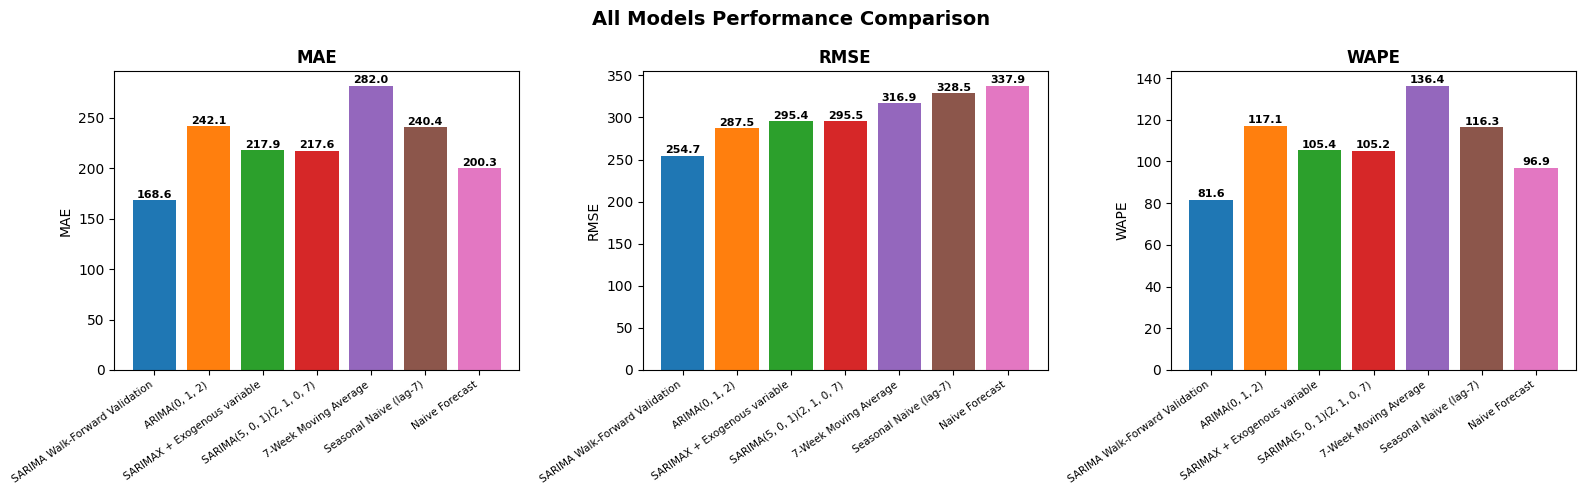

In [32]:
results_df = pd.DataFrame(evaluation_results).sort_values('RMSE')

print()
print("="*68)
print("   MODEL COMPARISON  (lower RMSE/MAE/WAPE/sMAPE = better)")
print("="*68)
print(f'\n{results_df.to_string(index=False)}')
print("="*68)

# Visual bar chart comparison
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'WAPE', 'SMAPE']):
    colors = sns.color_palette('tab10', len(results_df))
    bars = ax.bar(range(len(results_df)), results_df[metric], color=colors)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=7.5)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+0.3,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('All Models Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [33]:
forecast_results.sort_values('MAE')

,Model,MAE,RMSE,WAPE,SMAPE,R Square
8,SARIMA Walk-Forward Validation,168.640000,254.690000,81.580000,111.040000,0.200000
1,XGBoost with lag,183.205627,265.404541,88.625008,117.165584,0.127753
2,Naive Forecast,200.340000,337.850000,96.910000,148.190000,-0.410000
0,XGBoost B4 Lag,205.776093,296.974194,99.543388,134.826032,-0.092095
6,"SARIMA(5, 0, 1)(2, 1, 0, 7)",217.570000,295.490000,105.250000,110.100000,-0.080000
7,SARIMAX + Exogenous variable,217.880000,295.390000,105.400000,108.870000,-0.080000
3,Seasonal Naive (lag-7),240.450000,328.470000,116.320000,109.060000,-0.340000
5,"ARIMA(0, 1, 2)",242.080000,287.490000,117.100000,128.700000,-0.020000
4,7-Week Moving Average,282.040000,316.850000,136.430000,126.800000,-0.240000


Residual diagnostics indicate that the SARIMA walk-forward model adequately captures the temporal structure of appointment demand. Residuals fluctuate around zero without obvious systematic patterns, while the residual ACF shows limited remaining autocorrelation. The Ljung-Box test does not indicate statistically significant residual autocorrelation, suggesting that the remaining errors are approximately random. Therefore, the model is considered suitable for generating future appointment-demand forecasts.

In [34]:
# Saving essentials in data folder
'''
daily_demand.to_csv("../data/daily_demand.csv", index=True) 
forecast_results.to_csv("../data/forecast_results.csv", index=False)'''


'\ndaily_demand.to_csv("../data/daily_demand.csv", index=True) \nforecast_results.to_csv("../data/forecast_results.csv", index=False)'

## Generating Future Forecasts

In [44]:
forecast_result = sarima_fit.get_forecast(steps=30)
future_forecast = forecast_result.predicted_mean

conf_int = forecast_result.conf_int()

last_date = ts.index.max()
future_dates = pd.date_range(
    start = last_date + pd.Timedelta(days=1),
    periods = 30,
    freq = 'D' 
)

future_forecast_df = pd.DataFrame({
    'forecast_date': future_dates,
    'forecast': future_forecast.values,
    'lower_ci': conf_int.iloc[:,0].values,
    'upper_ci': conf_int.iloc[:,1].values
})

future_forecast_df.head()

,forecast_date,forecast,lower_ci,upper_ci
0,2021-05-13,480.976840,145.892118,816.061561
1,2021-05-14,296.678254,-67.684068,661.040576
2,2021-05-15,269.387952,-117.990296,656.766200
3,2021-05-16,511.033504,116.046063,906.020945
4,2021-05-17,513.733538,114.579672,912.887404


In [45]:
# Saving it in folder

future_forecast_df.to_csv("../data/future_forecast.csv", index=False)

In [46]:
future_forecast_df = pd.read_csv("../data/future_forecast.csv")

print(future_forecast_df.head())
print(future_forecast_df.tail())
print(future_forecast_df.shape)

  forecast_date    forecast    lower_ci    upper_ci
0    2021-05-13  480.976840  145.892118  816.061561
1    2021-05-14  296.678254  -67.684068  661.040576
2    2021-05-15  269.387952 -117.990296  656.766200
3    2021-05-16  511.033504  116.046063  906.020945
4    2021-05-17  513.733538  114.579672  912.887404
   forecast_date    forecast    lower_ci     upper_ci
25    2021-06-07  468.325642 -132.307410  1068.958695
26    2021-06-08   34.737013 -567.142991   636.617017
27    2021-06-09   30.684332 -571.310586   632.679250
28    2021-06-10  458.609419 -184.498083  1101.716921
29    2021-06-11  290.593975 -358.293626   939.481577
(30, 4)
